## SubGraph

**Subgraph** - A graph as a node used in another graph. - Allows to build complex systems with multiple components themselves.

Useful for: 
- Building Multiagent systems
- Increasing Code reusability - reuseable logic can be prepared as graphs
- Promotes composable design where subgraphs can be independently composed to main graph

#### Adding Subgraph to parent graph
There are 2 ways to add subgraph to parent graph:
- Compiled subgraph is added as a node to the parent graph for this parent and subgraph should share at least one key which can be used to communicate
- Add a node with a function that invokes the subgraph. Useful when parent and subgraph have differnet schema, and need to transfrer the state before calling the subgraph.

#### Communication between parent and subgraph
2 scenerios by which parent and subgraph can pass state between each other during execution:
- Parent graph and subgraph share schema keys, In this case node can be added as a compiled subgraph.
- Diff schema: Node function needs to be added that invokes a subgraph: this is useful when the parent graph and the subgraph have different state schemas and need to transform state before or after calling it.

In [1]:
from warnings import filterwarnings
filterwarnings('ignore')

import os
from dotenv import load_dotenv
from langchain_aws import ChatBedrockConverse
load_dotenv()

os.environ['LANGCHAIN_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ["LANGCHAIN_TRACING_V2"] = "true" # Enable LangSmith tracing
os.environ['LANGSMITH_PROJECT'] = 'LangGraphTraining' 

model = ChatBedrockConverse(model= "us.anthropic.claude-sonnet-4-6",)

[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [3]:
from langgraph.graph import START, END, StateGraph, MessagesState
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import tools_condition, ToolNode

from langchain_core.messages import HumanMessage, SystemMessage

from operator import add
from typing import TypedDict, Annotated

### Parent Node and Schema

In [4]:
class TravelPlannerState(TypedDict):
    user_msg: Annotated[str, add]
    messages: Annotated[str, add]

# defining agent
def travel_planner_agent(state: TravelPlannerState):
    return {'user_msg': state['user_msg']}

### Defining subgraphs

#### Flight

In [5]:
# Flight
class FlightState(TypedDict):
    user_msg: Annotated[str, add]
    messages: Annotated[str, add]
    
# defining agent
def flight_agent(state: FlightState):
    sys_msg =  " You provide the 2 best flight options for the given destination and dates."
    human_msg = state["user_msg"]
    prompt = sys_msg + human_msg
    response = model.invoke(prompt)    
    return {"messages":response.content}

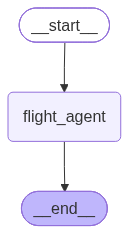

In [6]:
flight_graph_builder = StateGraph(FlightState)
flight_graph_builder.add_node("flight_agent",flight_agent)
flight_graph_builder.add_edge(START,"flight_agent")
flight_graph_builder.add_edge("flight_agent",END)
flight_graph = flight_graph_builder.compile()
flight_graph

#### Hotel

In [ ]:
class HotelState(TypedDict):
    user_msg: Annotated[str, add]
    messages: Annotated[str, add]
    
# defining agent
def hotel_agent(state: HotelState):
    sys_msg =  " You provide the 2 best hotel options for the given destination and dates."
    human_msg = state["user_msg"]
    prompt = sys_msg + human_msg
    response = model.invoke(prompt)
    return {"messages":response.content} 

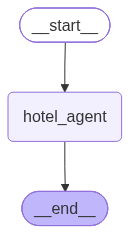

In [8]:
hotel_graph_builder = StateGraph(HotelState)
hotel_graph_builder.add_node("hotel_agent",hotel_agent)
hotel_graph_builder.add_edge(START,"hotel_agent")
hotel_graph_builder.add_edge("hotel_agent",END)
hotel_graph = hotel_graph_builder.compile()
hotel_graph

#### Activity Agent

In [9]:
class ActivityState(TypedDict):
    user_msg: Annotated[str, add]
    messages: Annotated[str, add]
    
# defining agent
def activity_agent(state: ActivityState):
    sys_msg =  " You provide the 2 best activities options for the given destination."
    human_msg = state["user_msg"]
    prompt = sys_msg + human_msg
    response = model.invoke(prompt)
    return {"messages":response.content} 

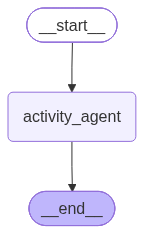

In [10]:
activity_graph_builder = StateGraph(ActivityState)
activity_graph_builder.add_node("activity_agent",activity_agent)
activity_graph_builder.add_edge(START,"activity_agent")
activity_graph_builder.add_edge("activity_agent",END)
activity_graph = activity_graph_builder.compile()
activity_graph

#### Resturant Agent

In [11]:
class RestaurantState(TypedDict):
    user_msg: Annotated[str, add]
    messages: Annotated[str, add]

def restaurant_agent(state: RestaurantState):
    sys_msg =  " You provide the 2 best restaurants options for the given destination."
    human_msg = state["user_msg"]
    prompt = sys_msg + human_msg
    response = model.invoke(prompt)
    return {"messages":response.content}  

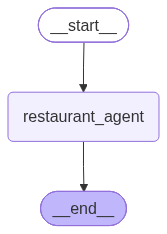

In [12]:
resturant_graph_builder = StateGraph(RestaurantState)
resturant_graph_builder.add_node("restaurant_agent",restaurant_agent)
resturant_graph_builder.add_edge(START,"restaurant_agent")
resturant_graph_builder.add_edge("restaurant_agent",END)
resturant_graph = resturant_graph_builder.compile()
resturant_graph

#### Parent Agent

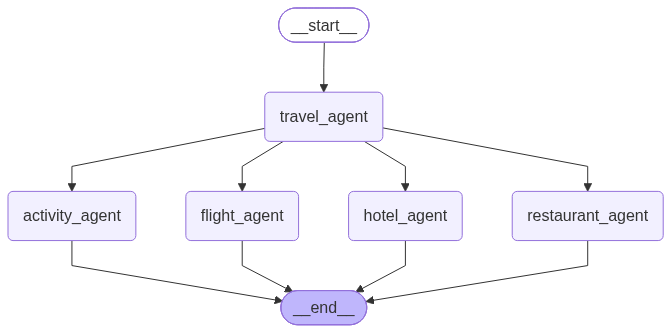

In [14]:
travel_planner_builder = StateGraph(TravelPlannerState)

travel_planner_builder.add_node('travel_agent',travel_planner_agent)
travel_planner_builder.add_node('flight_agent',flight_agent)
travel_planner_builder.add_node('hotel_agent',hotel_agent)
travel_planner_builder.add_node('activity_agent',activity_agent)
travel_planner_builder.add_node('restaurant_agent',restaurant_agent)

travel_planner_builder.add_edge(START,'travel_agent')
travel_planner_builder.add_edge('travel_agent','flight_agent')
travel_planner_builder.add_edge('travel_agent','hotel_agent')
travel_planner_builder.add_edge('travel_agent','activity_agent')
travel_planner_builder.add_edge('travel_agent','restaurant_agent')

travel_planner_builder.add_edge('flight_agent',END)
travel_planner_builder.add_edge('hotel_agent',END)
travel_planner_builder.add_edge('activity_agent',END)
travel_planner_builder.add_edge('restaurant_agent',END)

travel_planner_graph = travel_planner_builder.compile()
travel_planner_graph


#### Invoking the Graph

In [15]:
input = 'I am planning to visit mumbai at budget, for 2 days and a night and then I have to catch a bus to pune, I am taking a train to Mumbai reaching on 13th Sept, I need to stay at 13th night in hotel along with that on 14th, there is Ganesh Chaturthi, Which I want to explore and enjoy in Mumbai, Help me make a plan for this trip, then on 14th Late night planning to go pune.'
response = travel_planner_graph.invoke({"user_msg":input})
print(response['messages'])

# 🎉 Mumbai Budget Trip Plan - 13th & 14th September

---

## 📅 DAY 1 - 13th September (Arrival Day)

### 🚂 Arrival & Check-in
- Arrive at **Mumbai Central / CST Station**
- Head to hotel and freshen up

### 🏨 Budget Hotel Recommendations
| Hotel | Area | Approx Cost |
|-------|------|-------------|
| Hotel Decent | Dadar | ₹800-1200/night |
| Hotel City Inn | CST Area | ₹1000-1500/night |

> 💡 **Pro Tip:** Stay near **Dadar** - It's the **BEST location** for Ganesh Chaturthi celebrations!

---

### 🌆 Evening/Night Plan - 13th Sept

#### ✅ Activity 1 - Gateway of India & Marine Drive
- Visit **Gateway of India**
- Stroll along **Marine Drive** (Queen's Necklace at night)
- Budget dinner at nearby local restaurants
- **Cost:** Almost Free | **Time:** 3-4 hours

#### ✅ Activity 2 - Pre-Ganesh Chaturthi Atmosphere
- Visit **Dadar Flower Market** (Decorations begin night before)
- Watch **Ganesh idol installations** happening across streets
- Feel the electric **pre-festival energy**
- **Co

In [19]:
from IPython.display import Markdown
Markdown(response['messages'])

# 🎉 Mumbai Budget Trip Plan - 13th & 14th September

---

## 📅 DAY 1 - 13th September (Arrival Day)

### 🚂 Arrival & Check-in
- Arrive at **Mumbai Central / CST Station**
- Head to hotel and freshen up

### 🏨 Budget Hotel Recommendations
| Hotel | Area | Approx Cost |
|-------|------|-------------|
| Hotel Decent | Dadar | ₹800-1200/night |
| Hotel City Inn | CST Area | ₹1000-1500/night |

> 💡 **Pro Tip:** Stay near **Dadar** - It's the **BEST location** for Ganesh Chaturthi celebrations!

---

### 🌆 Evening/Night Plan - 13th Sept

#### ✅ Activity 1 - Gateway of India & Marine Drive
- Visit **Gateway of India**
- Stroll along **Marine Drive** (Queen's Necklace at night)
- Budget dinner at nearby local restaurants
- **Cost:** Almost Free | **Time:** 3-4 hours

#### ✅ Activity 2 - Pre-Ganesh Chaturthi Atmosphere
- Visit **Dadar Flower Market** (Decorations begin night before)
- Watch **Ganesh idol installations** happening across streets
- Feel the electric **pre-festival energy**
- **Cost:** Free | **Time:** 2 hours

---

## 📅 DAY 2 - 14th September (Ganesh Chaturthi 🙏)

### 🌅 Morning (7 AM - 12 PM)

#### 🏆 TOP ACTIVITY 1 - Lalbaugcha Raja
- Visit the **Most Famous Ganesh Pandal** in Mumbai
- Reach **EARLY morning (7-8 AM)** to avoid massive crowds
- Located at **Lalbaug, Parel**
- **Darshan + Experience:** 2-3 hours
- **Cost:** Free ✅
- 🚇 Nearest Station: **Curry Road / Chinchpokli**

---

### 🌞 Afternoon (12 PM - 4 PM)

#### 🏆 TOP ACTIVITY 2 - Ganesh Pandal Hopping
**Must Visit Pandals:**
- 🥇 **GSB Seva Mandal** - Known for Gold & Silver decorations
- 🥈 **Keshavji Naik Chawl** - Historic & Grand
- 🥉 **Andheri Cha Raja** - Huge crowds & amazing décor

> 🎵 Enjoy **dhol-tasha**, **aarti**, free **prasad** everywhere!

---

### 🍽️ Budget Food Options
| Food | Place | Cost |
|------|-------|------|
| Vada Pav | Any street stall | ₹15-20 |
| Thali Meal | Local restaurant | ₹100-150 |
| Pav Bhaji | Dadar stalls | ₹80-100 |
| Festival Prasad | Pandals | FREE 😄 |

---

### 🌙 Evening to Night (6 PM - 11 PM)

- Watch **Ganesh Aarti** at major pandals (7-8 PM)
- Experience **processions & celebrations** on streets
- Enjoy **cultural performances & lighting**
- Click memories 📸
- **Head back to hotel** - Pack your bags 🎒

---

### 🚌 Late Night - Catch Bus to Pune

| Bus Option | Departure | Cost |
|------------|-----------|------|
| MSRTC Shivneri | 11 PM - 12 AM | ₹350-500 |
| Private Volvo | 10 PM onwards | ₹400-700 |
| ZipCity/IntrCity | 11 PM onwards | ₹300-500 |

> 📍 **Board from:** Dadar Bus Depot or Mumbai Central
> ⏱️ **Journey Time:** 3-4 hours to Pune

---

## 💰 Total Budget Estimate

| Expense | Cost |
|---------|------|
| Hotel (1 night) | ₹800-1200 |
| Food (2 days) | ₹400-600 |
| Local Travel | ₹200-300 |
| Bus to Pune | ₹350-500 |
| **Total** | **₹1750-2600** |

---

## ⚠️ Important Tips
- 📱 **Book bus tickets in advance** - Heavy demand during Ganesh Chaturthi
- 👟 Wear **comfortable shoes** - Lots of walking
- 🎒 Carry **light bag** for festival day
- 💧 Stay **hydrated** - September is humid
- 📸 **Charge your phone** fully for photos

---

> 🙏 **Have a wonderful Ganesh Chaturthi in Mumbai!**
> **Ganpati Bappa Morya! 🎊**# 🎉 Mumbai Budget Trip Plan – 13th & 14th September

---

## 🏨 HOTEL RECOMMENDATION (Budget Stay – 13th Night)

### Since it's Ganesh Chaturthi season, book **IN ADVANCE!**

| Option | Hotel | Area | Est. Price/Night |
|--------|-------|------|-----------------|
| ⭐ Best Pick | **Hotel Decent** or **Hotel Rupam** | Dadar (Heart of celebrations!) | ₹800–₹1,500 |
| 💰 Budget Alt | **Zostel Mumbai** / **Backpacker Panda** | Colaba/Churchgate | ₹500–₹900 (dorm) |

> 💡 **Pro Tip:** Stay near **Dadar or Lalbaug** — these are the **epicenters** of Ganesh Chaturthi celebrations!

---

## 📅 DAY 1 – 13th September (Arrival Day)

### 🚂 Train Arrival at Mumbai (CST / Dadar / Lokmanya Tilak Terminal)

---

### 🕐 Afternoon (Post Arrival)
- ✅ Check into hotel
- ✅ Freshen up & have lunch
- 🍽️ **Where to Eat:** Lunch at **Aaswad Restaurant, Dadar** – Famous for Misal Pav & Maharashtrian thali (~₹100–₹150)

---

### 🌆 Evening – 13th Sept (Pre-Festival Vibe!)
| Time | Activity | Details |
|------|----------|---------|
| 4:00 PM | **Visit Dadar Flower Market** | Huge decorations & festive shopping – FREE |
| 5:30 PM | **Shivaji Park, Dadar** | Watch pandal setups & pre-festival energy |
| 7:00 PM | **Stroll at Marine Drive** | Iconic sunset walk – FREE |
| 8:30 PM | **Dinner at Juhu Beach** | Pav Bhaji, Bhel Puri (~₹80–₹150) |
| 10:00 PM | Return to hotel & rest 😴 | **Save energy for BIG day tomorrow!** |

---

## 📅 DAY 2 – 14th September 🙏 GANESH CHATURTHI

> **This is THE day! Mumbai transforms into a massive celebration!**

---

### 🌅 Morning
| Time | Activity | Details |
|------|----------|---------|
| 6:00 AM | **Wake up EARLY!** | Streets fill up fast! |
| 6:30 AM | **Breakfast** | Poha/Upma at local stall (~₹30–₹50) |
| 7:00 AM | **Lalbaugcha Raja** | Mumbai's MOST famous Ganesh pandal – **MUST VISIT** 🏆 |

> ⚠️ **Warning:** Lalbaugcha Raja lines can be **4–8 hours long** for darshan. Go early morning for shorter wait OR enjoy from outside if short on time!

---

### 🏛️ Famous Pandals to Cover (by Local Train!)

| Priority | Pandal | Area | Why Visit |
|----------|--------|------|-----------|
| 🥇 | **Lalbaugcha Raja** | Lalbaug | Most famous in Mumbai |
| 🥈 | **GSB Seva Mandal** | Kings Circle | Richest Ganesh – gold decorated |
| 🥉 | **Khetwadi Ganpati** | Khetwadi | Massive idol, grand decor |
| 4th | **Andhericha Raja** | Andheri | Popular & grand |
| 5th | **Chinchpoklicha Chintamani** | Chinchpokli | One of oldest in Mumbai |

---

### 🚇 How to Travel Between Pandals
```
Use LOCAL TRAINS 🚆 – Cheapest & Fastest on this day!
Lalbaug → Kings Circle → Dadar → Andheri
Cost: ₹10–₹20 per trip
```

---

### 🍽️ Lunch – 14th Sept
- 📍 **Panshikar Hotel or local dhabas near Dadar**
- 🥘 Try **Puran Poli, Modak, Varan Bhaat** – Festival special food!
- 💰 Cost: ~₹100–₹150

---

### 🌇 Afternoon / Evening
| Time | Activity |
|------|----------|
| 2:00 PM | Explore **Dadar Chowpatty** – Festive crowd, food stalls |
| 3:30 PM | Visit **Siddhivinayak Temple** – Iconic Ganesh Temple 🙏 |
| 5:00 PM | Back to **Girgaon Chowpatty** – Pre-Visarjan (Immersion) atmosphere |
| 6:00 PM | Watch **Aarti & Cultural Performances** at pandals |

---

### 🌊 Evening – VISARJAN (Immersion Procession!)
| Time | Activity |
|------|----------|
| 7:00 PM | Head to **Girgaon Chowpatty or Juhu Beach** |
| 7:30 PM | Watch grand **Ganpati Visarjan procession** 🎺🥁 |
| 8:30 PM | Enjoy **street food dinner** at Chowpatty (~₹100) |
| 9:30 PM | Head back, **checkout from hotel**, collect luggage |

---

## 🚌 PUNE BUS – 14th Late Night

### Mumbai → Pune Bus Options

| Option | Bus | Departure Point | Departure Time | Cost | Duration |
|--------|-----|----------------|----------------|------|----------|
| ⭐ Best | **Shivneri (MSRTC)** | Dadar / Mumbai Central | 10:30 PM – 12:00 AM | ₹350–₹450 | ~3.5 hrs |
| 💰 Budget | **MSRTC Sleeper/Semi-Sleeper** | Mumbai Central | 11:00 PM onwards | ₹250–₹350 | ~4 hrs |
| 🛏️ Comfort | **RedBus / ZingBus Private** | Multiple Points | 10 PM – 1 AM | ₹400–₹700 | ~3.5 hrs |

> 💡 **Book bus ticket in advance on RedBus or MSRTC website** – Ganesh Chaturthi = HEAVY rush toward Pune!

---

## 💰 TOTAL BUDGET ESTIMATE

| Expense | Cost |
|---------|------|
| 🏨 Hotel (1 night) | ₹800–₹1,500 |
| 🍽️ Food (2 days) | ₹500–₹700 |
| 🚇 Local transport | ₹150–₹200 |
| 🚌 Bus to Pune | ₹300–₹500 |
| 🎪 Misc/Pandal entry | ₹100–₹200 |
| **💵 TOTAL** | **₹1,850 – ₹3,100** |

---

## ✅ QUICK CHECKLIST

- [ ] 🎫 Book hotel near Dadar **NOW** (high demand!)
- [ ] 🚌 Book Mumbai→Pune bus in advance
- [ ] 👟 Wear comfortable footwear (lots of walking!)
- [ ] 💧 Carry water bottle
- [ ] 📱 Download **Google Maps & RailYatri app**
- [ ] 💳 Keep **cash** handy (street vendors)
- [ ] 🎒 Keep bag **light & secure** (huge crowds!)
- [ ] 📸 Fully charge your phone – great photo moments!

---

> 🙏 **Ganpati Bappa Morya!** You're going to experience one of India's BIGGEST festivals in the BEST city for it. Have an amazing trip! 🎊# 🏙️ Mumbai Trip Plan - Ganesh Chaturthi Special
## 📅 September 13-14, 2024

---

## 🏨 TOP 2 BUDGET HOTEL OPTIONS

### 🥇 Hotel 1: Hotel Monarch
> **Location: Near CST / Byculla**

| Detail | Info |
|--------|------|
| 📍 Location | Byculla, Central Mumbai |
| 💰 Price | ₹800 - ₹1,200/night |
| ⭐ Rating | 3.5/5 |
| ✅ Why Choose | Close to CST Station, Easy access to Ganesh pandals, Budget friendly |

---

### 🥈 Hotel 2: Hotel City Palace
> **Location: Near CST Station**

| Detail | Info |
|--------|------|
| 📍 Location | Near CST, Fort Area |
| 💰 Price | ₹1,000 - ₹1,500/night |
| ⭐ Rating | 3.8/5 |
| ✅ Why Choose | Prime location, Walking distance to famous pandals, Good reviews |

> 💡 **Pro Tip:** Book in advance! Hotels fill up fast during Ganesh Chaturthi

---

## 📋 DAY-BY-DAY TRIP PLAN

---

## 🚂 Day 1 - September 13th (Arrival Day)

### 🌆 Evening/Night Schedule

```
Train Arrives Mumbai → Check-in Hotel → Rest → Evening Explore
```

| Time | Activity | Details |
|------|----------|---------|
| 🕐 Arrival | Reach Mumbai CST/LTT | Collect luggage, arrange transport |
| 🕒 +1 Hour | Hotel Check-in | Freshen up & Rest |
| 🌆 7:00 PM | Local Dinner | Try Vada Pav, Pav Bhaji at roadside stalls |
| 🌃 9:00 PM | Pre-Chaturthi Excitement | Pandal preparations happening everywhere! |
| 🌙 Night | Hotel Rest | Sleep early for big day tomorrow! |

### 🍽️ Food Spots Near CST
- **Cream Centre** - Famous Mumbai snacks
- **Bademiyan** - Iconic street food (Colaba)
- **Any local tapri** - Authentic Vada Pav ₹15-₹20

---

## 🎉 Day 2 - September 14th (GANESH CHATURTHI!)

### 🌅 Morning Schedule

| Time | Activity | Details |
|------|----------|---------|
| ⏰ 7:00 AM | Wake up Early | Get ready comfortably |
| 🍳 7:30 AM | Breakfast | Hotel breakfast or nearby café |
| 🚶 8:30 AM | Start Pandal Hopping | Begin early to avoid huge crowds |

---

### 🐘 MUST VISIT GANESH PANDALS

```
⭐ MOST FAMOUS PANDALS IN MUMBAI ⭐
```

| # | Pandal Name | Location | Speciality |
|---|------------|----------|------------|
| 1 | **Lalbaugcha Raja** | Lalbaug, Central Mumbai | Most Famous, King of all Pandals |
| 2 | **GSB Seva Ganesh** | King's Circle | Richest Ganesh (Gold & Silver) |
| 3 | **Keshavji Naik Chawl** | Girgaon | Very Oldest Ganesh Mumbai |
| 4 | **Andhericha Raja** | Andheri | Popular with Bollywood celebs |
| 5 | **Chinchpoklicha Chintamani** | Chinchpokli | Over 100 years old |

> ⚠️ **Important:** Lalbaugcha Raja queue can be **10-20 hours** on Chaturthi day!
> Consider **darshan from outside** to save time

---

### 🗺️ RECOMMENDED PANDAL ROUTE

```
Hotel → Chinchpoklicha Chintamani → Keshavji Naik Chawl 
→ GSB Ganesh → Lalbaugcha Raja (View from outside) → Marine Drive
```

### 🕐 Detailed Timeline

| Time | Activity |
|------|----------|
| 8:30 AM | **Chinchpoklicha Chintamani** - Start here (less crowd in morning) |
| 10:30 AM | **Keshavji Naik Chawl Ganesh** - Historic pandal |
| 12:30 PM | **Lunch Break** - Street food feast! |
| 2:00 PM | **GSB Seva Ganesh** - Stunning decoration |
| 4:00 PM | **Lalbaugcha Raja** - View from outside, soak in atmosphere |
| 6:00 PM | **Marine Drive** - Evening walk, watch city celebrations |
| 7:30 PM | **Dinner** - Proper sit-down meal before journey |
| 9:00 PM | **Hotel Checkout & Luggage collection** |
| 10:00 PM | **Head to Pune Bus Stop** |
| 11:00 PM | **Board Bus to Pune** 🚌 |

---

## 🚌 PUNE BUS INFORMATION

### Bus Terminals in Mumbai for Pune

| Terminal | Location | Best For |
|----------|----------|---------|
| **Mumbai Central Bus Depot** | Mumbai Central | Private & MSRTC buses |
| **Dadar Bus Stand** | Dadar | Convenient from Central Mumbai |
| **Sion Bus Stop** | Sion | Multiple private operators |

### Recommended Bus Options

| Bus Type | Price | Duration | Comfort |
|----------|-------|----------|---------|
| **MSRTC Shivneri** | ₹350-₹450 | 3.5-4 hrs | ⭐⭐⭐⭐ |
| **Neeta Tours** | ₹300-₹400 | 4 hrs | ⭐⭐⭐⭐ |
| **Parvati Travels** | ₹250-₹350 | 4 hrs | ⭐⭐⭐ |
| **VRL / Orange Travels** | ₹400-₹500 | 3.5 hrs | ⭐⭐⭐⭐ |

> 💡 **Book bus in advance on RedBus or MakeMyTrip** - Chaturthi period = heavy rush!

---

## 💰 BUDGET BREAKDOWN

| Expense | Estimated Cost |
|---------|---------------|
| 🏨 Hotel (1 Night) | ₹800 - ₹1,500 |
| 🚂 Local Transport (Mumbai) | ₹200 - ₹300 |
| 🍽️ Food (2 Days) | ₹400 - ₹600 |
| 🚌 Bus to Pune | ₹300 - ₹450 |
| 🎉 Miscellaneous | ₹200 - ₹300 |
| **💵 TOTAL** | **₹1,900 - ₹3,150** |

---

## ⚠️ IMPORTANT TIPS FOR GANESH CHATURTHI

```
🔴 MUST KNOW BEFORE YOU GO
```

- 📱 **Keep phone charged** - Carry power bank
- 👟 **Wear comfortable shoes** - Lots of walking
- 💧 **Stay Hydrated** - Carry water bottle
- 📦 **Keep luggage at hotel** - Don't carry bags to pandals
- 🚇 **Use Mumbai Local Train** - Fastest way to travel
- 👮 **Heavy crowd expected** - Stay alert, watch belongings
- 📸 **Keep camera ready** - Stunning decorations everywhere
- 🌧️ **September = Monsoon** - Carry umbrella/raincoat
- 🕐 **Early morning visit** = Less crowd + better experience
- 📞 **Save hotel number** - In case of emergency

---

## 🚇 LOCAL TRANSPORT GUIDE

| Route | Transport | Time | Cost |
|-------|-----------|------|------|
| CST → Lalbaug | Local Train | 15 mins | ₹10 |
| Lalbaug → King's Circle | Local Train | 10 mins | ₹10 |
| Any Pandal → Marine Drive | Auto/Taxi | 20-30 mins | ₹80-150 |
| Hotel → Dadar Bus Stand | Auto | 15-20 mins | ₹60-100 |

---

## 🎊 EXPERIENCE HIGHLIGHTS

> **What makes this trip SPECIAL:**

- 🥁 **Dhol-tasha beats** everywhere you walk
- 🌸 **Flower decorations** on every street
- 🙏 **Aarti experience** - Participate in morning/evening aarti
- 🎭 **Cultural performances** at major pandals
- 🍭 **Modak & prasad** - Must taste!
- 📸 **Incredible photo opportunities** - Artistic Ganesh idols
- 🌊 **Pre-visarjan energy** - City is electric with joy!

---

## ✅ QUICK CHECKLIST

- [ ] Train ticket confirmed
- [ ] Hotel booked in advance
- [ ] Bus to Pune booked (RedBus)
- [ ] Power bank charged
- [ ] Comfortable shoes
- [ ] Raincoat/Umbrella (Monsoon!)
- [ ] Cash in hand (many places don't take cards)
- [ ] ID proof

---

> ### 🙏 Ganpati Bappa Morya! Have an Amazing Trip! 🎉
> *Mumbai during Ganesh Chaturthi is a once-in-a-lifetime experience. Enjoy every moment!*# 🎉 Mumbai Budget Trip Plan - 13th & 14th September

---

## 🚂 DAY 1 - 13th September (Arrival Day)

### Upon Arrival at Mumbai
> **First Priority: Check into Hotel**

### 🏨 Budget Hotel Recommendations
| Hotel | Location | Approx Cost |
|-------|----------|-------------|
| **Hotel Decent** | Dadar (Central Location) | ₹800-1200/night |
| **Hotel Rupam** | Dadar/CST Area | ₹1000-1500/night |

> 💡 **Why Dadar?** Best location for Ganesh Chaturthi - **Dadar is the HEART of the festival!**

---

### 🌆 13th September Evening Plan
```
Arrive → Check-in → Freshen Up → Evening Exploration
```

**Evening Itinerary:**
- 🌊 **Marine Drive** - Evening walk (Free)
- 🌅 **Chowpatty Beach** - Watch pre-festival preparations
- 👀 **Scout Ganpati Pandals** being set up in your area
- 🌙 **Gateway of India** - Night view (Free)

---

### 🍽️ Restaurant Recommendations - Day 1

| # | Restaurant | Specialty | Approx Cost |
|---|-----------|-----------|-------------|
| 🥇 | **Aaswad Restaurant, Dadar** | Authentic Maharashtrian Thali | ₹150-250/person |
| 🥈 | **Panshikar Food Mall, Dadar** | Local Mumbai Street Food | ₹100-200/person |

---

## 🙏 DAY 2 - 14th September (GANESH CHATURTHI!)

### 🎊 Festival Day - Complete Plan

---

### ☀️ Morning (6:00 AM - 12:00 PM)
```
⏰ 6:00 AM - Wake up EARLY (Festival starts early!)
🛁 6:30 AM - Get Ready
🍳 7:00 AM - Quick Breakfast
🎉 7:30 AM - Start Pandal Hopping
```

### 🏆 Must-Visit Ganpati Pandals in Mumbai

| Pandal | Location | Famous For |
|--------|----------|------------|
| **Lalbaugcha Raja** | Lalbaug | Most Famous, Wish-Fulfilling |
| **GSB Seva Ganesh** | King's Circle | Richest Ganpati (Gold Decor) |
| **Andhericha Raja** | Andheri | Largest Idol |
| **Dadarcha Raja** | Dadar | Near your Hotel |
| **Keshavji Naik Chawl** | Girgaon | Oldest Ganpati |

> ⚠️ **Important Note:** Lalbaugcha Raja will have **MASSIVE queues** - Plan 3-4 hours waiting time or go early morning!

---

### 🌞 Afternoon (12:00 PM - 5:00 PM)
```
🍽️ 12:30 PM - Lunch
🎭 2:00 PM - Continue Pandal Hopping
📸 3:00 PM - Photography & Enjoying Festivities
🎶 4:00 PM - Enjoy Cultural Programs at Pandals
```

---

### 🍽️ Restaurant Recommendations - Day 2 (Festival Day)

| # | Restaurant | Specialty | Approx Cost |
|---|-----------|-----------|-------------|
| 🥇 | **Prakash Upahaar Kendra, Dadar** | Traditional Maharashtrian - Puran Poli & Modak | ₹100-200/person |
| 🥈 | **Hotel Swati Snacks, Tardeo** | Mumbai's Famous Snacks & Thali | ₹200-300/person |

> 🍬 **Don't Miss:** **Modak** - Lord Ganesha's favorite sweet, available at every corner during festival!

---

### 🌆 Evening (5:00 PM - 10:00 PM)
```
🌊 5:00 PM - Visit Juhu Beach or Chowpatty
🎉 6:00 PM - Watch Aarti at Major Pandals
🥁 7:00 PM - Enjoy Dhol-Tasha performances
🎆 8:00 PM - Watch Evening celebrations & lights
🍜 9:00 PM - Dinner
```

---

### 🌙 Late Night - 14th September (Bus to Pune)

### 🚌 Bus Options - Mumbai to Pune

| Bus Service | Departure Point | Time | Approx Cost |
|-------------|----------------|------|-------------|
| **Shivneri (MSRTC)** | Dadar/Mumbai Central | 11 PM - 12 AM | ₹300-400 |
| **Neeta Tours** | Dadar | 10 PM - 12 AM | ₹250-350 |
| **IntrCity/RedBus** | Various Points | Multiple slots | ₹400-600 |

> 💡 **Book bus tickets in advance** - 14th Sept being festival day, buses fill up quickly!

---

## 💰 Budget Breakdown

| Expense | Estimated Cost |
|---------|---------------|
| 🏨 Hotel (1 Night) | ₹800 - 1,500 |
| 🍽️ Food (2 Days) | ₹600 - 1,000 |
| 🚇 Local Transport | ₹200 - 400 |
| 🚌 Bus to Pune | ₹300 - 600 |
| 🎯 Miscellaneous | ₹200 - 300 |
| **💵 TOTAL** | **₹2,100 - 3,800** |

---

## 🚇 Getting Around Mumbai (Budget Tips)

```
✅ Use Local Trains - Cheapest & Fastest
✅ BEST Buses - Economical for short distances  
✅ Auto/Cab - Only when necessary
❌ Avoid Peak Hours (8-10 AM, 5-8 PM)
```

---

## ⚠️ Important Tips for Ganesh Chaturthi

> 🔴 **Must Read Before Going!**

- 👟 **Wear Comfortable Shoes** - You'll walk A LOT
- 💧 **Carry Water Bottle** - Stay Hydrated in crowds
- 📱 **Keep Phone Charged** - Powerbank recommended
- 👜 **Keep Bag in Front** - Beware of pickpockets in crowds
- 📋 **Book Hotel in Advance** - Rates go up on festival days
- 🚌 **Book Bus in Advance** - Via RedBus/AbhiBus apps
- 🌙 **Lalbaugcha Raja at Night** looks absolutely MAGICAL

---

## 🗺️ Quick Day Summary

```
13th Sept → Arrive Mumbai → Check-in Hotel (Dadar) 
         → Evening Sightseeing → Dinner → Rest

14th Sept → Early Morning → Pandal Hopping 
         → Lalbaugcha Raja → Lunch → More Pandals 
         → Evening Aarti → Dinner → 🚌 Bus to Pune!
```

---

**Have an Amazing Trip & Ganpati Bappa Morya! 🙏🎉**

In [18]:
len(response['messages'])

18985

### Case 2: Parent graph and Subgrpah have different Schemas

In [20]:
# Schemas

class TripState(TypedDict):
    '''Parent state: Foucses on the overall Journey'''
    destination: str
    total_budget_inr: float
    local_currency_code: str
    converted_spending: float
    itinerary_status: str

class CurrencyState(TypedDict):
    '''Subgraph state: Foucus on financil math'''
    amount: float
    from_iso: str
    to_iso: str
    rate: float
    result: float

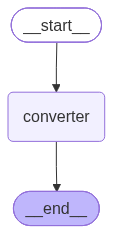

In [21]:
# Currency subgraph:
def fetch_exchange_rate(state: CurrencyState):
    '''API call to travel forex provider'''
    rates = {'USD': 0.0105, 'EUR': 0.009, 'JPY': 1.66}
    current_rate = rates.get(state["to_iso"], 1.0)

    return {
        'rate': current_rate,
        'result': state['amount'] * current_rate
    }

sub_builder = StateGraph(CurrencyState)
sub_builder.add_node('converter', fetch_exchange_rate)
sub_builder.add_edge(START, 'converter')
sub_builder.add_edge('converter', END)
currency_subgraph = sub_builder.compile()
currency_subgraph

In [22]:
# Creating the parent forex graph
def forex_manager_node(state: TripState) -> TripState:
    '''
    Acts as the bridge. It translates the Trip itinerary 
    into a format the Currency subgraph understands.
    '''
    print(f"--- Parent: Managing currency for {state['destination']} ---")
    
    sub_input: CurrencyState = {
        "amount": state["total_budget_inr"],
        "from_iso": "INR",
        "to_iso": state["local_currency_code"],
        "rate": 0.0,
        "result": 0.0
    }
    
    # Invocation
    forex_result = currency_subgraph.invoke(sub_input)
    return {
        'converted_spending': forex_result['result'],
        'itinerary_status': f"Budget confirmed in {state['local_currency_code']}"
    }

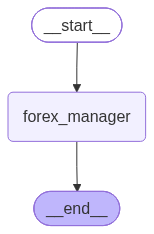

In [23]:
# Parent Graph
builder = StateGraph(TripState)
builder.add_node("forex_manager", forex_manager_node)
builder.add_edge(START, "forex_manager")
builder.add_edge("forex_manager", END)

travel_app = builder.compile()
travel_app

In [27]:
trip_data = {
    "destination": "Tokyo, Japan",
    "total_budget_inr": 250000.0,
    "local_currency_code": "JPY",
    "converted_spending": 0.0,
    "itinerary_status": "Planning"
}

output = travel_app.invoke(trip_data)

print("\n--- Final Itinerary Update ---")
print(f"Status: {output['itinerary_status']}")
print(f"Total Budget in {trip_data['local_currency_code']}: {output['converted_spending']:,}")

--- Parent: Managing currency for Tokyo, Japan ---

--- Final Itinerary Update ---
Status: Budget confirmed in JPY
Total Budget in JPY: 415,000.0
